# PA / PB1 peptide design — protocol comparison

Loads ColabDesign generation/optimisation results and Boltz structural validation,
then compares protocols on both sets of metrics.

In [2]:
import json, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='tab10')
pd.set_option('display.float_format', '{:.3f}'.format)

## 1. Paths

In [3]:
SHARED = pathlib.Path('../../../../')

SCRIPT_DIR = SHARED / 'protein_design/colabdesign_energy_guidance/prg/PA_PB1'
COLAB_DIR  = SCRIPT_DIR / 'results'          # *.json from colabdesign runs
BOLTZ_DIR  = SHARED / 'protein_design/boltz/results'  # boltz_results_pa_<name>/

print(f'COLAB_DIR  exists: {COLAB_DIR.exists()}  ({len(list(COLAB_DIR.glob("*.json")))} JSON files)')
print(f'BOLTZ_DIR  exists: {BOLTZ_DIR.exists()}')

COLAB_DIR  exists: True  (12 JSON files)
BOLTZ_DIR  exists: True


## 2. Load ColabDesign results

In [4]:
def load_colab_results(colab_dir: pathlib.Path) -> pd.DataFrame:
    rows = []
    for jf in sorted(colab_dir.glob('*.json')):
        proto = jf.stem
        data  = json.loads(jf.read_text())
        for i, entry in enumerate(data.get('results', [])):
            rows.append({
                'name'       : f'{proto}_{i}',
                'protocol'   : proto,
                'idx'        : i,
                'seq'        : entry.get('seq', ''),
                'loss_total' : entry.get('loss_total'),
                'loss_af'    : entry.get('loss_af'),
                'energy'     : entry.get('energy'),
                'colab_iptm' : entry.get('i_ptm'),
                'colab_ptm'  : entry.get('ptm'),
                'colab_plddt': entry.get('plddt'),
            })
    if not rows:
        raise RuntimeError(f'No results found in {colab_dir} — check COLAB_DIR path above.')
    df = pd.DataFrame(rows)
    print(f'Loaded {len(df)} ColabDesign entries from {df["protocol"].nunique()} protocols')
    return df

df_colab = load_colab_results(COLAB_DIR)
df_colab.head()

Loaded 180 ColabDesign entries from 12 protocols


,name,protocol,idx,seq,loss_total,loss_af,energy,colab_iptm,colab_ptm,colab_plddt
0,gen_colabonly_0,gen_colabonly,0,AAGGPAALVLLLCLD,3.829,3.829,5.030,0.395,0.898,0.391
1,gen_colabonly_1,gen_colabonly,1,SSGGALGDALLVMLN,3.902,3.902,12.613,0.349,0.879,0.377
2,gen_colabonly_2,gen_colabonly,2,AAGGGDALLCLLMLD,3.779,3.779,5.422,0.376,0.879,0.378
3,gen_colabonly_3,gen_colabonly,3,AAGGGGDGALLLMCM,4.216,4.216,10.376,0.236,0.873,0.319
4,gen_colabonly_4,gen_colabonly,4,LSPGALALCVLLMCD,3.527,3.527,11.810,0.585,0.906,0.489


## 3. Load Boltz results

In [42]:
BOLTZ_COLS = [
    'name', 'boltz_confidence', 'boltz_ptm', 'boltz_iptm',
    'boltz_plddt', 'boltz_iplddt', 'boltz_pde', 'boltz_ipde',
    'boltz_ptm_PA', 'boltz_ptm_pep', 'boltz_iptm_cross',
]

def load_boltz_results(boltz_dir: pathlib.Path) -> pd.DataFrame:
    """
    Expected output layout created by run_boltz_peptides.sh:
      boltz_dir/
        boltz_results_pa_<name>/
          predictions/
            pa_<name>/
              confidence_pa_<name>_model_0.json
    Returns an empty DataFrame with the correct schema if no results are found.
    """
    rows = []
    for result_dir in sorted(boltz_dir.glob('boltz_results_pa_*')):
        name = result_dir.name.removeprefix('boltz_results_pa_')
        conf_glob = list(result_dir.glob(f'predictions/pa_{name}/confidence_pa_{name}_model_0.json'))
        if not conf_glob:
            print(f'  [missing] {result_dir.name}')
            continue
        conf = json.loads(conf_glob[0].read_text())
        rows.append({
            'name'             : name,
            'boltz_confidence' : conf.get('confidence_score'),
            'boltz_ptm'        : conf.get('ptm'),
            'boltz_iptm'       : conf.get('iptm'),
            'boltz_plddt'      : conf.get('complex_plddt'),
            'boltz_iplddt'     : conf.get('complex_iplddt'),
            'boltz_pde'        : conf.get('complex_pde'),
            'boltz_ipde'       : conf.get('complex_ipde'),
            'boltz_ptm_PA'     : conf.get('chains_ptm', {}).get('0'),
            'boltz_ptm_pep'    : conf.get('chains_ptm', {}).get('1'),
            'boltz_iptm_cross' : conf.get('pair_chains_iptm', {}).get('1', {}).get('0'),
        })
    if not rows:
        print('No Boltz results found — returning empty table.')
        return pd.DataFrame(columns=BOLTZ_COLS)
    df = pd.DataFrame(rows)
    print(f'Loaded {len(df)} Boltz entries')
    return df

df_boltz = load_boltz_results(BOLTZ_DIR)
df_boltz.head()

Loaded 186 Boltz entries


,name,boltz_confidence,boltz_ptm,boltz_iptm,boltz_plddt,boltz_iplddt,boltz_pde,boltz_ipde,boltz_ptm_PA,boltz_ptm_pep,boltz_iptm_cross
0,gen_colabonly_0,0.897,0.949,0.952,0.884,0.860,0.362,1.143,0.949,0.968,0.952
1,gen_colabonly_1,0.819,0.936,0.620,0.869,0.799,0.495,5.283,0.947,0.743,0.620
2,gen_colabonly_10,0.895,0.935,0.939,0.885,0.831,0.389,1.403,0.935,0.959,0.939
3,gen_colabonly_11,0.896,0.929,0.948,0.883,0.839,0.406,1.375,0.929,0.970,0.948
4,gen_colabonly_12,0.890,0.927,0.945,0.876,0.836,0.408,1.286,0.927,0.964,0.945


## 4. Merge

In [43]:
df = df_colab.merge(df_boltz, on='name', how='left')
n_matched = df['boltz_confidence'].notna().sum()
print(f'{n_matched}/{len(df)} entries have Boltz results')
df.head()

180/180 entries have Boltz results


,name,protocol,idx,seq,loss_total,loss_af,energy,colab_iptm,colab_ptm,colab_plddt,boltz_confidence,boltz_ptm,boltz_iptm,boltz_plddt,boltz_iplddt,boltz_pde,boltz_ipde,boltz_ptm_PA,boltz_ptm_pep,boltz_iptm_cross
0,gen_colabonly_0,gen_colabonly,0,AAGGPAALVLLLCLD,3.829,3.829,5.030,0.395,0.898,0.391,0.897,0.949,0.952,0.884,0.860,0.362,1.143,0.949,0.968,0.952
1,gen_colabonly_1,gen_colabonly,1,SSGGALGDALLVMLN,3.902,3.902,12.613,0.349,0.879,0.377,0.819,0.936,0.620,0.869,0.799,0.495,5.283,0.947,0.743,0.620
2,gen_colabonly_2,gen_colabonly,2,AAGGGDALLCLLMLD,3.779,3.779,5.422,0.376,0.879,0.378,0.865,0.934,0.842,0.871,0.790,0.445,3.265,0.938,0.938,0.842
3,gen_colabonly_3,gen_colabonly,3,AAGGGGDGALLLMCM,4.216,4.216,10.376,0.236,0.873,0.319,0.889,0.945,0.887,0.890,0.854,0.376,1.786,0.948,0.902,0.887
4,gen_colabonly_4,gen_colabonly,4,LSPGALALCVLLMCD,3.527,3.527,11.810,0.585,0.906,0.489,0.885,0.928,0.929,0.874,0.848,0.430,1.797,0.928,0.982,0.929


## 5. Per-protocol summary statistics

In [44]:
METRICS = [
    'loss_af', 'energy', 'colab_iptm', 'colab_ptm', 'colab_plddt',
    'boltz_confidence', 'boltz_iptm', 'boltz_plddt', 'boltz_iplddt', 'boltz_iptm_cross',
]

available = [m for m in METRICS if m in df.columns and df[m].notna().any()]

summary = (
    df.groupby('protocol')[available]
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .round(3)
)
summary

loss_af                         energy               \
                       mean   std   min   max count   mean   std    min   
protocol                                                                  
gen_colabonly         3.857 0.180 3.527 4.216    20  7.495 2.672  2.455   
gen_energy_A          3.961 0.142 3.749 4.293    20 -3.174 1.182 -5.680   
gen_energy_B          3.945 0.255 3.384 4.492    20 -4.144 1.517 -6.347   
gen_energy_C          3.934 0.300 3.206 4.574    20 -6.364 1.239 -8.276   
opt_anneal_energy_A   5.181 0.645 4.231 6.471    20 -1.857 2.294 -4.592   
opt_anneal_energy_B   5.181 0.645 4.231 6.471    20 -1.857 2.294 -4.592   
opt_anneal_energy_C   5.336 0.801 3.810 6.805    20 -3.152 1.273 -5.681   
opt_anneal_noenergy   4.942 0.824 2.952 6.534    20  0.208 4.087 -5.878   
opt_hard_energy_A     6.205 0.635 5.505 6.805     5 -1.785 2.174 -3.506   
opt_hard_energy_B     6.205 0.635 5.505 6.805     5 -1.785 2.174 -3.506   
opt_hard_energy_C     6.205 0.635 5.505 6.805     5 -1.785 2.174 -3.506   
opt_hard_noenergy     6.205 0.635 5.505 6.805     5 -1.785 2.174 -3.506   

                                  ... boltz_iplddt                          \
                       max count  ...         mean   std   min   max count   
protocol                          ...                                        
gen_colabonly       12.613    20  ...        0.831 0.031 0.777 0.883    20   
gen_energy_A        -1.082    20  ...        0.845 0.033 0.794 0.898    20   
gen_energy_B        -0.294    20  ...        0.849 0.039 0.777 0.909    20   
gen_energy_C        -4.303    20  ...        0.837 0.042 0.764 0.903    20   
opt_anneal_energy_A  5.652    20  ...        0.814 0.037 0.759 0.881    20   
opt_anneal_energy_B  5.652    20  ...        0.826 0.044 0.745 0.901    20   
opt_anneal_energy_C -0.353    20  ...        0.828 0.048 0.742 0.890    20   
opt_anneal_noenergy  9.351    20  ...        0.816 0.036 0.756 0.891    20   
opt_hard_energy_A    1.257     5  ...        0.824 0.043 0.782 0.882     5   
opt_hard_energy_B    1.257     5  ...        0.829 0.044 0.793 0.891     5   
opt_hard_energy_C    1.257     5  ...        0.806 0.037 0.773 0.867     5   
opt_hard_noenergy    1.257     5  ...        0.821 0.036 0.780 0.874     5   

                    boltz_iptm_cross                          
                                mean   std   min   max count  
protocol                                                      
gen_colabonly                  0.878 0.104 0.607 0.965    20  
gen_energy_A                   0.912 0.072 0.705 0.959    20  
gen_energy_B                   0.898 0.084 0.598 0.962    20  
gen_energy_C                   0.896 0.117 0.547 0.967    20  
opt_anneal_energy_A            0.887 0.053 0.811 0.966    20  
opt_anneal_energy_B            0.873 0.107 0.598 0.967    20  
opt_anneal_energy_C            0.854 0.138 0.551 0.970    20  
opt_anneal_noenergy            0.906 0.051 0.781 0.969    20  
opt_hard_energy_A              0.896 0.043 0.852 0.947     5  
opt_hard_energy_B              0.894 0.069 0.784 0.954     5  
opt_hard_energy_C              0.911 0.014 0.897 0.932     5  
opt_hard_noenergy              0.893 0.050 0.810 0.930     5  

[12 rows x 50 columns]

## 6. Visualisations
### 6.1 Box plots — ColabDesign metrics

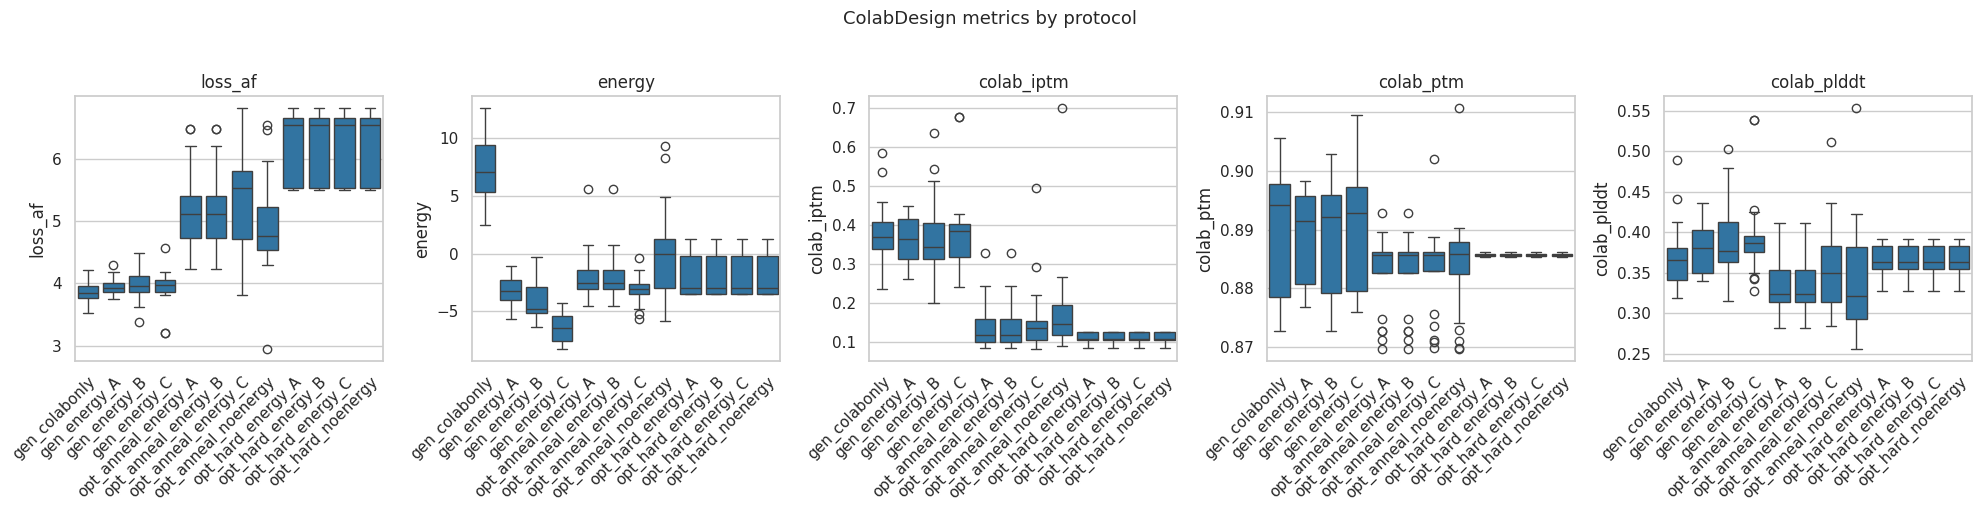

In [45]:
colab_metrics = ['loss_af', 'energy', 'colab_iptm', 'colab_ptm', 'colab_plddt']
colab_metrics = [m for m in colab_metrics if m in df.columns]

fig, axes = plt.subplots(1, len(colab_metrics), figsize=(4*len(colab_metrics), 5), sharey=False)
for ax, metric in zip(axes, colab_metrics):
    sns.boxplot(data=df, x='protocol', y=metric, ax=ax, order=sorted(df['protocol'].unique()))
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor')
fig.suptitle('ColabDesign metrics by protocol', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Box plots — Boltz metrics

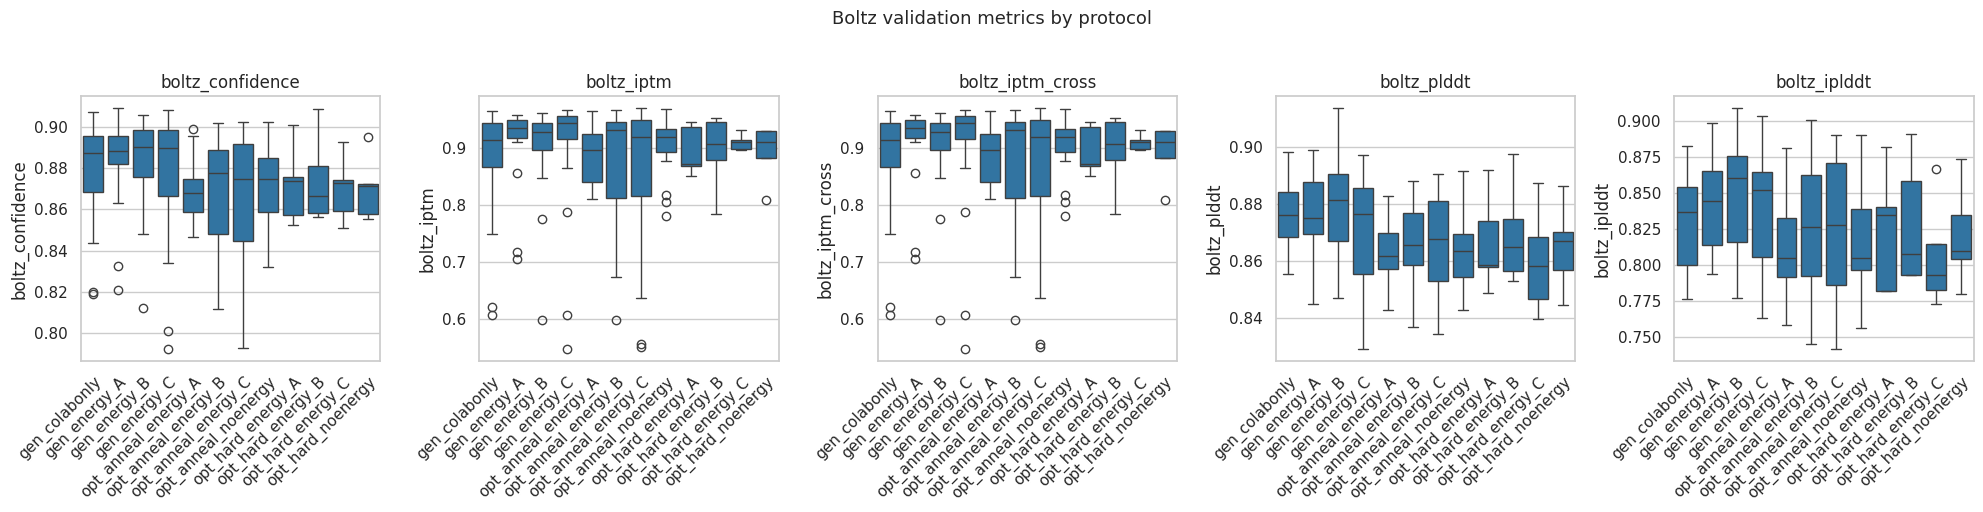

In [46]:
boltz_metrics = ['boltz_confidence', 'boltz_iptm', 'boltz_iptm_cross', 'boltz_plddt', 'boltz_iplddt']
boltz_metrics = [m for m in boltz_metrics if m in df.columns and df[m].notna().any()]

if boltz_metrics:
    fig, axes = plt.subplots(1, len(boltz_metrics), figsize=(4*len(boltz_metrics), 5), sharey=False)
    if len(boltz_metrics) == 1:
        axes = [axes]
    for ax, metric in zip(axes, boltz_metrics):
        sns.boxplot(data=df, x='protocol', y=metric, ax=ax, order=sorted(df['protocol'].unique()))
        ax.set_title(metric)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)
        plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor')
    fig.suptitle('Boltz validation metrics by protocol', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No Boltz results available yet.')

### 6.3 ColabDesign vs Boltz correlation

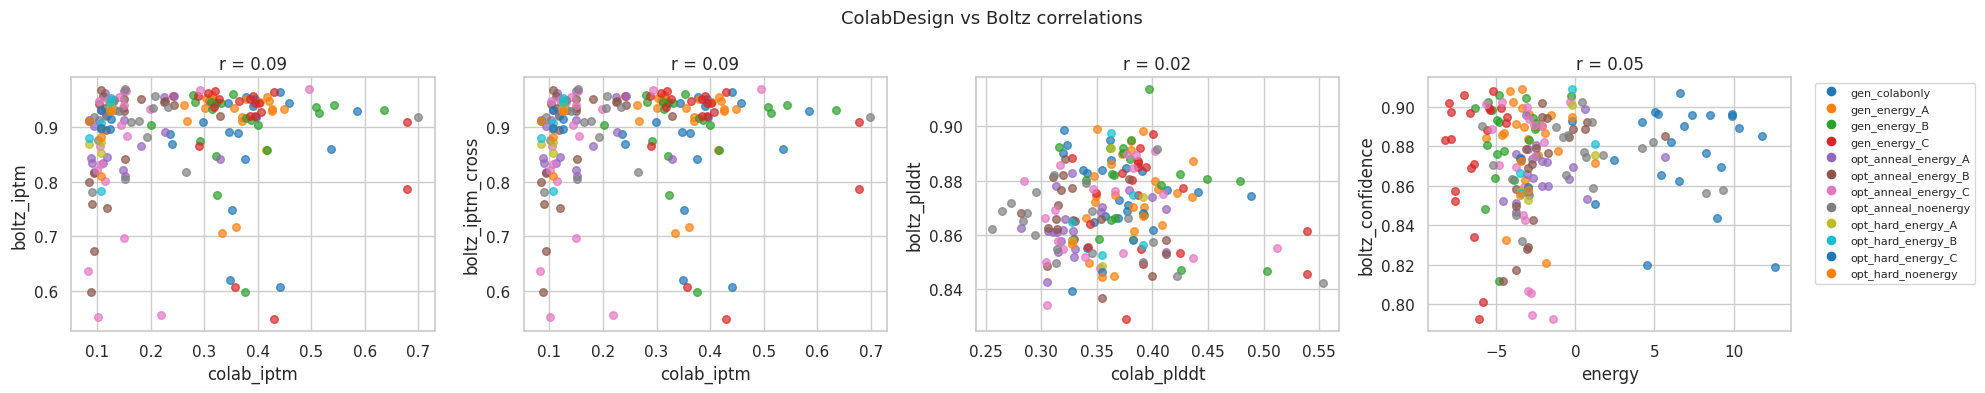

In [47]:
pairs = [
    ('colab_iptm',  'boltz_iptm'),
    ('colab_iptm',  'boltz_iptm_cross'),
    ('colab_plddt', 'boltz_plddt'),
    ('energy',      'boltz_confidence'),
]
pairs = [(x, y) for x, y in pairs
         if x in df.columns and y in df.columns and df[y].notna().any()]

if pairs:
    fig, axes = plt.subplots(1, len(pairs), figsize=(5*len(pairs), 4))
    if len(pairs) == 1:
        axes = [axes]
    protos  = sorted(df.protocol.unique())
    palette = dict(zip(protos, sns.color_palette('tab10', len(protos))))
    for ax, (xcol, ycol) in zip(axes, pairs):
        for proto, grp in df.dropna(subset=[xcol, ycol]).groupby('protocol'):
            ax.scatter(grp[xcol], grp[ycol], label=proto, alpha=0.7,
                       color=palette[proto], s=30)
        ax.set_xlabel(xcol); ax.set_ylabel(ycol)
        r = df[[xcol, ycol]].dropna().corr().iloc[0, 1]
        ax.set_title(f'r = {r:.2f}')
    handles = [plt.Line2D([0],[0], marker='o', color='w',
                           markerfacecolor=palette[p], label=p, markersize=8)
               for p in protos]
    axes[-1].legend(handles=handles, bbox_to_anchor=(1.05,1), loc='upper left', fontsize=8)
    fig.suptitle('ColabDesign vs Boltz correlations', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('No Boltz results to correlate yet.')

### 6.4 Protocol ranking — mean boltz_confidence

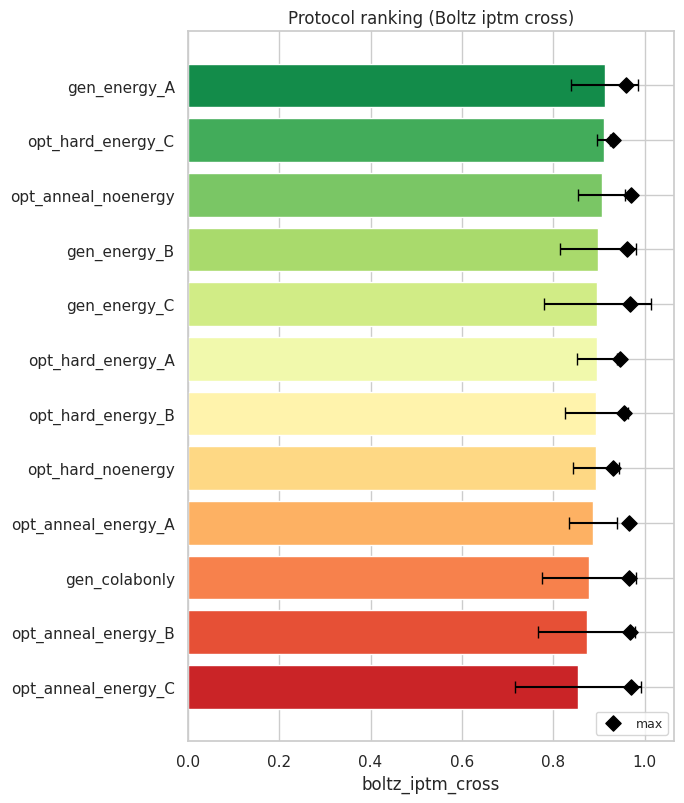

,mean,std,count,max
protocol,,,,
gen_energy_A,0.912,0.072,20,0.959
opt_hard_energy_C,0.911,0.014,5,0.932
opt_anneal_noenergy,0.906,0.051,20,0.969
gen_energy_B,0.898,0.084,20,0.962
gen_energy_C,0.896,0.117,20,0.967
opt_hard_energy_A,0.896,0.043,5,0.947
opt_hard_energy_B,0.894,0.069,5,0.954
opt_hard_noenergy,0.893,0.050,5,0.930
opt_anneal_energy_A,0.887,0.053,20,0.966


In [48]:
if df['boltz_confidence'].notna().any():
    rank = (
        df.groupby('protocol')['boltz_iptm_cross']
        .agg(['mean', 'std', 'count', 'max'])
        .sort_values('mean', ascending=False)
    )
    fig, ax = plt.subplots(figsize=(7, 0.6*len(rank)+1))
    colors = sns.color_palette('RdYlGn', len(rank))
    ax.barh(rank.index, rank['mean'], xerr=rank['std'], align='center',
            color=colors[::-1], capsize=4)
    ax.scatter(rank['max'], rank.index, color='black', zorder=5,
               s=60, marker='D', label='max')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlabel('boltz_iptm_cross')
    ax.set_title('Protocol ranking (Boltz iptm cross)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    display(rank)
else:
    print('No Boltz results available yet.')

### 6.5 Heatmap — mean metrics per protocol

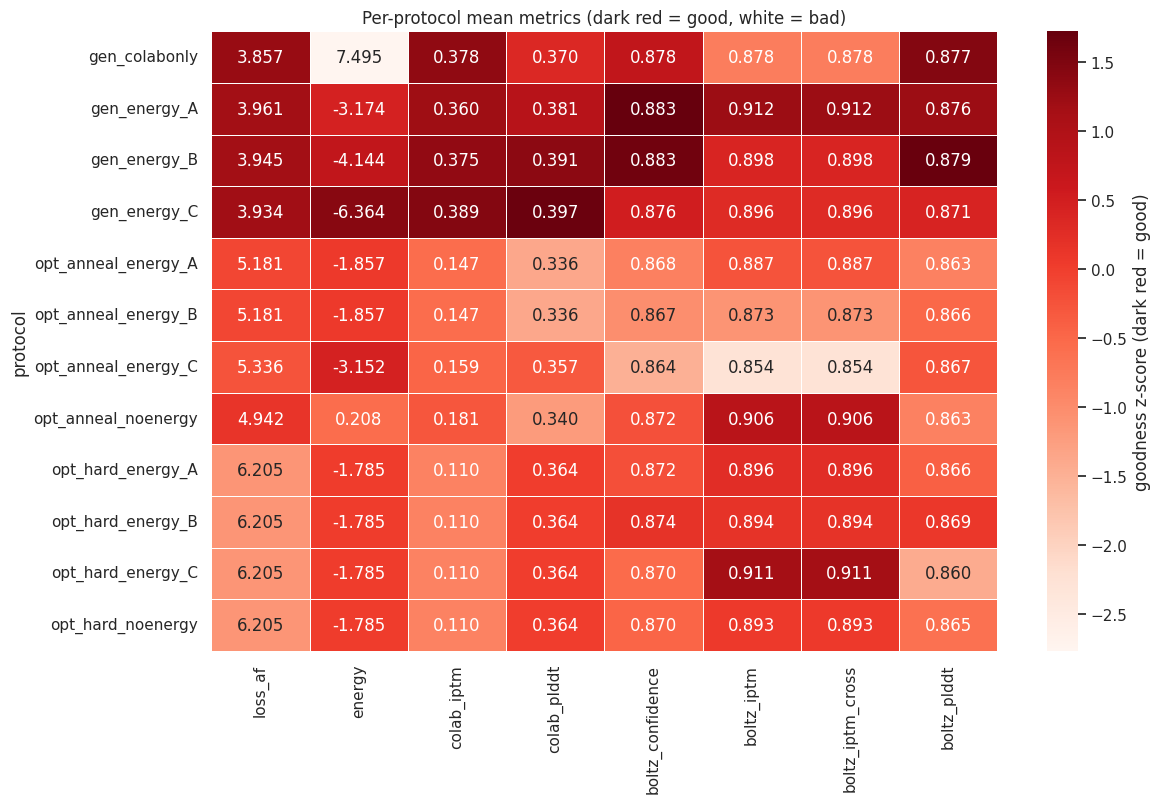

In [49]:
heat_cols = [m for m in [
    'loss_af', 'energy', 'colab_iptm', 'colab_plddt',
    'boltz_confidence', 'boltz_iptm', 'boltz_iptm_cross', 'boltz_plddt',
] if m in df.columns and df[m].notna().any()]

heat   = df.groupby('protocol')[heat_cols].mean()

# For lower-is-better metrics, flip the z-score so high always means good
LOWER_IS_BETTER = {'loss_af', 'energy', 'loss_total'}
heat_z = (heat - heat.mean()) / heat.std()
for col in heat_z.columns:
    if col in LOWER_IS_BETTER:
        heat_z[col] = -heat_z[col]

fig, ax = plt.subplots(figsize=(len(heat_cols)*1.4+1, len(heat)*0.6+1))
sns.heatmap(heat_z, annot=heat.round(3), fmt='.3f', cmap='Reds',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'goodness z-score (dark red = good)'})
ax.set_title('Per-protocol mean metrics (dark red = good, white = bad)')
plt.tight_layout()
plt.show()

## 7. Top candidates

In [50]:
sort_col = 'boltz_iptm_cross' if df.get('boltz_iptm_cross', pd.Series(dtype=float)).notna().any() else 'colab_iptm'
print(f'Ranking by: {sort_col}')

top = (
    df.dropna(subset=[sort_col])
    .sort_values(sort_col, ascending=False)
    .head(20)[['name', 'protocol', 'seq', 'colab_iptm', 'colab_plddt',
               'boltz_confidence', 'boltz_iptm', 'boltz_iptm_cross', 'boltz_plddt']]
    .reset_index(drop=True)
)
display(top)

Ranking by: boltz_iptm_cross


,name,protocol,seq,colab_iptm,colab_plddt,boltz_confidence,boltz_iptm,boltz_iptm_cross,boltz_plddt
0,opt_anneal_energy_C_2,opt_anneal_energy_C,SHGYVYDALWNMEVL,0.495,0.410,0.894,0.970,0.970,0.875
1,opt_anneal_noenergy_10,opt_anneal_noenergy,YHPQVEGSPELAMFL,0.153,0.284,0.886,0.969,0.969,0.865
2,opt_anneal_energy_C_7,opt_anneal_energy_C,YVCNVFDAFARMEVL,0.293,0.317,0.902,0.968,0.968,0.886
3,opt_anneal_energy_B_1,opt_anneal_energy_B,SHGYVYDWHKNMEVL,0.107,0.317,0.895,0.967,0.967,0.877
4,opt_anneal_energy_C_17,opt_anneal_energy_C,FWLDWMSSPNMKEWA,0.154,0.312,0.889,0.967,0.967,0.869
5,gen_energy_C_0,gen_energy_C,NWGSPAALLLFMCTC,0.319,0.373,0.899,0.967,0.967,0.883
6,opt_anneal_energy_A_17,opt_anneal_energy_A,FYLMMMSSPNMKEWA,0.149,0.313,0.896,0.966,0.966,0.878
7,gen_energy_C_13,gen_energy_C,LIGGPALEVLLCLFC,0.429,0.427,0.895,0.965,0.965,0.877
8,gen_colabonly_15,gen_colabonly,CCGDPALLFFLMCCE,0.441,0.401,0.882,0.965,0.965,0.862
9,gen_energy_C_17,gen_energy_C,EIGGLDAMLNYLLFC,0.308,0.388,0.906,0.963,0.963,0.892


In [51]:
OUT = SCRIPT_DIR / 'results' / 'top_candidates.csv'
top.to_csv(OUT, index=False)
print(f'Saved to {OUT}')

Saved to ../../../../protein_design/colabdesign_energy_guidance/prg/PA_PB1/results/top_candidates.csv


## 8. Sequence space — PCA + t-SNE

Each peptide is encoded as an integer vector of length 15 (one integer per position, 1–20 for the 20 standard amino acids).  
PCA is applied first to decorrelate and optionally reduce dimensionality; t-SNE then maps to 2-D.

### 8.1 Parameters

In [63]:
# ── Encoding ──────────────────────────────────────────────────────────────────
AA_ORDER   = 'ACDEFGHIKLMNPQRSTVWY'   # standard 20 AA → integers 1–20
AA_TO_INT  = {aa: i+1 for i, aa in enumerate(AA_ORDER)}

# ── PCA ───────────────────────────────────────────────────────────────────────
N_PCA       = 10 #10     # PCA components fed into t-SNE (None → skip PCA, use raw vectors)

# ── t-SNE ─────────────────────────────────────────────────────────────────────
PERPLEXITY  = 30     # typical range 5–50; try 10, 20, 30, 50
N_ITER      = 1000   # optimisation steps (≥250)
LEARNING_RATE = 'auto'  # 'auto' or a float (200 is a common default)
RANDOM_STATE  = 42

### 8.2 Encode sequences

In [59]:
def encode_sequence(seq: str, aa_to_int: dict, length: int = 15) -> np.ndarray:
    """Integer-encode a peptide sequence.  Unknown AAs are mapped to 0."""
    vec = np.zeros(length, dtype=np.float32)
    for i, aa in enumerate(seq[:length]):
        vec[i] = aa_to_int.get(aa, 0)
    return vec

SEQ_LEN = df['seq'].str.len().mode()[0]   # expected peptide length
print(f'Sequence length detected: {SEQ_LEN}')

# Filter to well-formed sequences only
mask  = df['seq'].str.len() == SEQ_LEN
df_ok = df[mask].reset_index(drop=True)
print(f'Sequences kept: {len(df_ok)}/{len(df)}')

X_raw = np.stack([encode_sequence(s, AA_TO_INT, SEQ_LEN) for s in df_ok['seq']])
print(f'Feature matrix: {X_raw.shape}  (values 0–20, 0 = unknown)')

Sequence length detected: 15
Sequences kept: 180/180
Feature matrix: (180, 15)  (values 0–20, 0 = unknown)


### 8.3 PCA — scree plot and projection

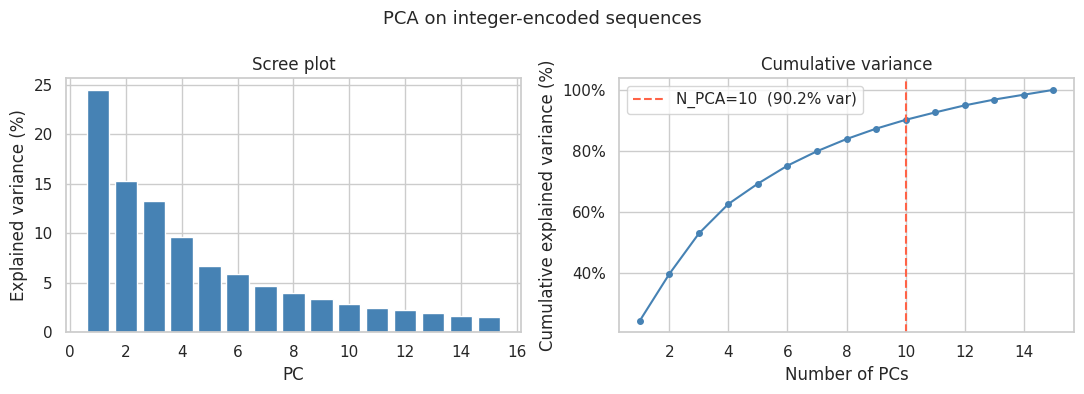

PCA: 15 → 10 dims  (90.2% variance retained)


In [64]:
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

evr     = pca_full.explained_variance_ratio_
cumevr  = np.cumsum(evr)
n_comps = len(evr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.bar(range(1, n_comps+1), evr * 100, color='steelblue')
ax1.set_xlabel('PC'); ax1.set_ylabel('Explained variance (%)')
ax1.set_title('Scree plot')

ax2.plot(range(1, n_comps+1), cumevr * 100, marker='o', color='steelblue', ms=4)
if N_PCA is not None:
    ax2.axvline(N_PCA, color='tomato', linestyle='--',
                label=f'N_PCA={N_PCA}  ({cumevr[N_PCA-1]*100:.1f}% var)')
    ax2.legend()
ax2.set_xlabel('Number of PCs'); ax2.set_ylabel('Cumulative explained variance (%)')
ax2.set_title('Cumulative variance')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.suptitle('PCA on integer-encoded sequences', fontsize=13)
plt.tight_layout()
plt.show()

# Reduce to N_PCA components for t-SNE input
if N_PCA is not None and N_PCA < X_scaled.shape[1]:
    pca_reduce = PCA(n_components=N_PCA, random_state=RANDOM_STATE)
    X_pca = pca_reduce.fit_transform(X_scaled)
    print(f'PCA: {X_scaled.shape[1]} → {N_PCA} dims  '
          f'({cumevr[N_PCA-1]*100:.1f}% variance retained)')
else:
    X_pca = X_scaled
    print('PCA skipped — using full scaled matrix')

### 8.4 t-SNE

In [65]:
tsne = TSNE(
    n_components  = 2,
    perplexity    = min(PERPLEXITY, len(X_pca) - 1),
    #n_iter        = N_ITER,
    learning_rate = LEARNING_RATE,
    random_state  = RANDOM_STATE,
    init          = 'pca',   # warm-start from PCA for stability
    verbose       = 1,
)
X_tsne = tsne.fit_transform(X_pca)
df_ok  = df_ok.assign(tsne_x=X_tsne[:, 0], tsne_y=X_tsne[:, 1])
print('t-SNE done. KL divergence:', round(tsne.kl_divergence_, 4))

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 180 samples in 0.000s...
[t-SNE] Computed neighbors for 180 samples in 0.006s...
[t-SNE] Computed conditional probabilities for sample 180 / 180
[t-SNE] Mean sigma: 2.112289
[t-SNE] KL divergence after 250 iterations with early exaggeration: 52.031483
[t-SNE] KL divergence after 1000 iterations: 0.223330
t-SNE done. KL divergence: 0.2233


### 8.5 t-SNE map — coloured by protocol

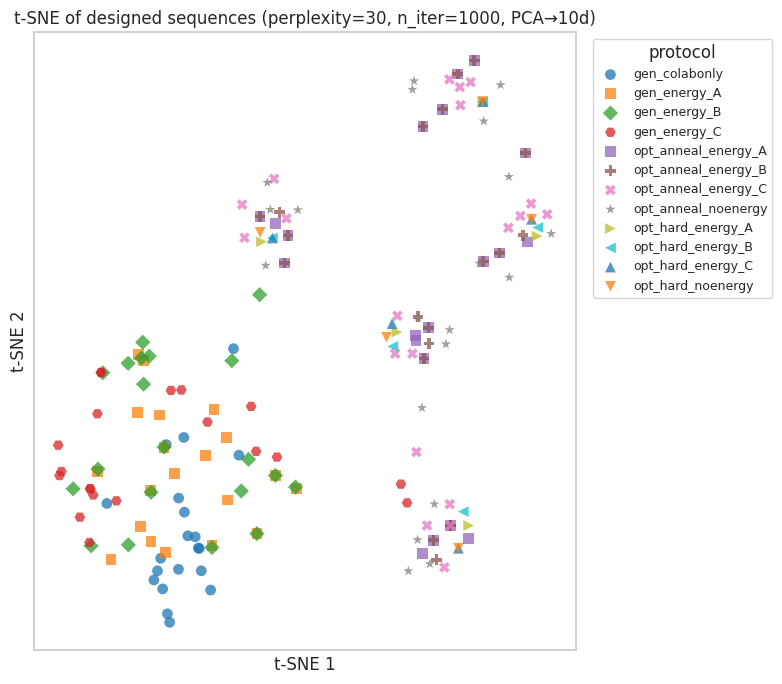

In [66]:
protos  = sorted(df_ok['protocol'].unique())
palette = dict(zip(protos, sns.color_palette('tab10', len(protos))))
markers = ['o', 's', 'D', 'H', ',', 'P', 'X', '*', '>', '<', '^', 'v',]   # one per protocol
mmap    = dict(zip(protos, markers))

fig, ax = plt.subplots(figsize=(8, 7))
for proto, grp in df_ok.groupby('protocol'):
    ax.scatter(
        grp['tsne_x'], grp['tsne_y'],
        color  = palette[proto],
        marker = mmap.get(proto, 'o'),
        s      = 60,
        alpha  = 0.75,
        label  = proto,
        edgecolors='none',
    )

ax.legend(title='protocol', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.set_title(
    f't-SNE of designed sequences (perplexity={PERPLEXITY}, '
    f'n_iter={N_ITER}, PCA→{N_PCA}d)'
)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

### 8.6 t-SNE map — coloured by quality metric

Same layout, but point colour encodes a continuous quality score (uses `boltz_iptm_cross` if available, else `colab_iptm`).  
This lets you see whether high-quality sequences cluster in a specific region of sequence space.

Quality metric: boltz_iptm_cross


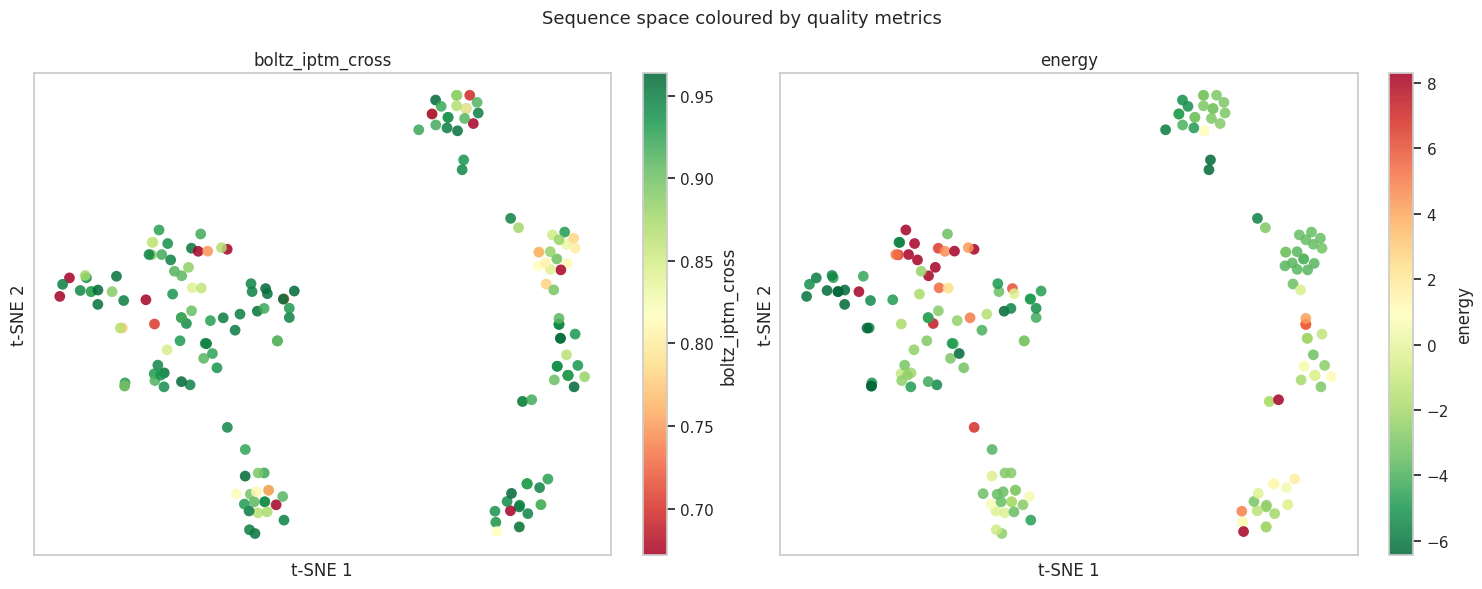

In [57]:
quality_col = (
    'boltz_iptm_cross'
    if 'boltz_iptm_cross' in df_ok.columns and df_ok['boltz_iptm_cross'].notna().any()
    else 'colab_iptm'
)
print(f'Quality metric: {quality_col}')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colormaps=['RdYlGn', 'RdYlGn_r']

for ax, col in zip(axes, [quality_col, 'energy']):
    vals = df_ok[col]
    sc = ax.scatter(
        df_ok['tsne_x'], df_ok['tsne_y'],
        c      = vals,
        cmap   = colormaps[0] if col == quality_col else colormaps[1],
        s      = 60,
        alpha  = 0.85,
        vmin   = vals.quantile(0.05),
        vmax   = vals.quantile(0.95),
        edgecolors='none',
    )
    plt.colorbar(sc, ax=ax, label=col, fraction=0.04)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.set_title(col)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle('Sequence space coloured by quality metrics', fontsize=13)
plt.tight_layout()
plt.show()